NAME: ADWAITH KRISHNA MH 

CLASS: R3AI

ROLL NO: B25CTA12

DATE: 31-08-2026

implement a decision tree classification algorithm using the id3 approach with entropy as the splitting criterion for the given tennis dataset. encode the categorical attributs, train and evaluate the model, visualize the decision tree and predict the outcome for a new test case

1. IMPORT LIBRARIES 

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

2. LOAD DATASET

In [36]:
file_path = r"C:\Users\adwai\Downloads\play_tennis_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset:")
print(df)

Dataset:
    Day   Outlook Temperature Humidity    Wind Play Tennis
0    D1     Sunny         Hot     High    Weak          No
1    D2     Sunny         Hot     High  Strong          No
2    D3  Overcast         Hot     High    Weak         Yes
3    D4      Rain        Mild     High    Weak         Yes
4    D5      Rain        Cool   Normal    Weak         Yes
5    D6      Rain        Cool   Normal  Strong          No
6    D7  Overcast        Cool   Normal  Strong         Yes
7    D8     Sunny        Mild     High    Weak          No
8    D9     Sunny        Cool   Normal    Weak         Yes
9   D10      Rain        Mild   Normal    Weak         Yes
10  D11     Sunny        Mild   Normal  Strong         Yes
11  D12  Overcast        Mild     High  Strong         Yes
12  D13  Overcast         Hot   Normal    Weak         Yes
13  D14      Rain        Mild     High  Strong          No


3. DISPLAY DATASET INFORMATION

In [37]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe(include="all"))

Dataset Shape:
(14, 6)

Column Names:
['Day', 'Outlook', 'Temperature', 'Humidity', 'Wind', 'Play Tennis']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Day          14 non-null     object
 1   Outlook      14 non-null     object
 2   Temperature  14 non-null     object
 3   Humidity     14 non-null     object
 4   Wind         14 non-null     object
 5   Play Tennis  14 non-null     object
dtypes: object(6)
memory usage: 804.0+ bytes
None

Statistical Summary:
       Day Outlook Temperature Humidity  Wind Play Tennis
count   14      14          14       14    14          14
unique  14       3           3        2     2           2
top     D1   Sunny        Mild     High  Weak         Yes
freq     1       5           6        7     8           9


4. CHECK FOR MISSING VALUES

In [38]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Day            0
Outlook        0
Temperature    0
Humidity       0
Wind           0
Play Tennis    0
dtype: int64


5. PREPARE THE DATASET

In [39]:
# Remove the Day column because it is only an identifier
X = df.drop(columns=["Day", "Play Tennis"])

# Select Play Tennis as the target variable
y = df["Play Tennis"]

print("Input Features:")
print(X)

print("\nTarget Variable:")
print(y)

Input Features:
     Outlook Temperature Humidity    Wind
0      Sunny         Hot     High    Weak
1      Sunny         Hot     High  Strong
2   Overcast         Hot     High    Weak
3       Rain        Mild     High    Weak
4       Rain        Cool   Normal    Weak
5       Rain        Cool   Normal  Strong
6   Overcast        Cool   Normal  Strong
7      Sunny        Mild     High    Weak
8      Sunny        Cool   Normal    Weak
9       Rain        Mild   Normal    Weak
10     Sunny        Mild   Normal  Strong
11  Overcast        Mild     High  Strong
12  Overcast         Hot   Normal    Weak
13      Rain        Mild     High  Strong

Target Variable:
0      No
1      No
2     Yes
3     Yes
4     Yes
5      No
6     Yes
7      No
8     Yes
9     Yes
10    Yes
11    Yes
12    Yes
13     No
Name: Play Tennis, dtype: object


6. ENCODE CATEGORICAL VALUES

In [40]:
# Create a dictionary to store encoders
encoders = {}

# Encode each categorical feature
for column in X.columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column])
    encoders[column] = encoder

# Encode target variable
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("Encoded Features:")
print(X)

print("\nEncoded Target:")
print(y)

Encoded Features:
    Outlook  Temperature  Humidity  Wind
0         2            1         0     1
1         2            1         0     0
2         0            1         0     1
3         1            2         0     1
4         1            0         1     1
5         1            0         1     0
6         0            0         1     0
7         2            2         0     1
8         2            0         1     1
9         1            2         1     1
10        2            2         1     0
11        0            2         0     0
12        0            1         1     1
13        1            2         0     0

Encoded Target:
[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


7. DISPLAY ENCODING MAPPINGS

In [41]:
print("Encoding Mappings:\n")

for column, encoder in encoders.items():
    print(column)
    for original, encoded in zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    ):
        print(original, "=", encoded)
    print()

print("Play Tennis")
for original, encoded in zip(
    target_encoder.classes_,
    target_encoder.transform(target_encoder.classes_)
):
    print(original, "=", encoded)

Encoding Mappings:

Outlook
Overcast = 0
Rain = 1
Sunny = 2

Temperature
Cool = 0
Hot = 1
Mild = 2

Humidity
High = 0
Normal = 1

Wind
Strong = 0
Weak = 1

Play Tennis
No = 0
Yes = 1


8. SPLIT DATASET 

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training Data:")
print(X_train)

print("\nTesting Data:")
print(X_test)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Data:
    Outlook  Temperature  Humidity  Wind
1         2            1         0     0
6         0            0         1     0
10        2            2         1     0
13        1            2         0     0
3         1            2         0     1
5         1            0         1     0
9         1            2         1     1
2         0            1         0     1
4         1            0         1     1

Testing Data:
    Outlook  Temperature  Humidity  Wind
11        0            2         0     0
12        0            1         1     1
0         2            1         0     1
8         2            0         1     1
7         2            2         0     1

Training Samples: 9
Testing Samples: 5


9. ID3 DECISION TREE CREATION 

In [43]:
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

print("ID3 Decision Tree created successfully.")

ID3 Decision Tree created successfully.


10. TRAIN MODEL

In [44]:
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

11. PREDICT TEST DATA

In [45]:
# Predict the output for test data
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[1 1 0 1 0]

Predicted Values:
[0 1 1 1 1]


12. EVALUATE ACCURACY

In [46]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.4
Accuracy Percentage: 40.0 %


13. CONFUSION MATRIX

In [47]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[0 2]
 [1 2]]


14. CLASSIFICATION REPORT 

In [48]:
print("Classification Report:")

print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_,
    zero_division=0
))

Classification Report:
              precision    recall  f1-score   support

          No       0.00      0.00      0.00         2
         Yes       0.50      0.67      0.57         3

    accuracy                           0.40         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.30      0.40      0.34         5



15. VISUALIZE DECISION TREE

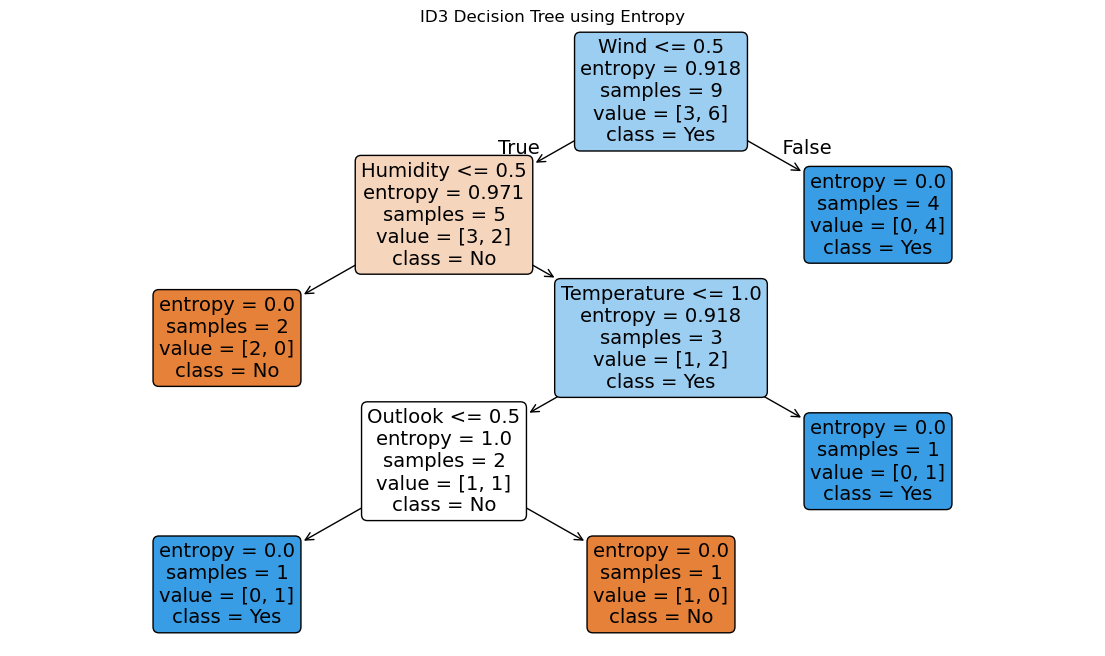

In [49]:
plt.figure(figsize=(14, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True
)

plt.title("ID3 Decision Tree using Entropy")
plt.show()